<a href="https://colab.research.google.com/github/KweonTJ/Machine_Learning/blob/main/6_Multi_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np

W, b = np.array([0.5, 0.5]), -0.7

In [7]:
def perceptron(x1, x2):
  x = np.array([x1, x2])
  tmp = np.sum(W*x) + b
  if tmp <= 0:
    return -1
  else:
    return 1

In [8]:
print('---퍼셉트론으로 구현한 AND Gate---')
for xs in [(-1, -1), (-1, 1), (1, -1), (1,1)]:
  y = perceptron(xs[0], xs[1])
  print(xs, ': ', y)

---퍼셉트론으로 구현한 AND Gate---
(-1, -1) :  -1
(-1, 1) :  -1
(1, -1) :  -1
(1, 1) :  1


In [9]:
W, b = np.array([0.7, 0.7]), .5
print('---퍼셉트론으로 구현한 OR Gate---')
for xs in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
  y = perceptron(xs[0], xs[1])
  print(xs, ': ', y)

---퍼셉트론으로 구현한 OR Gate---
(-1, -1) :  -1
(-1, 1) :  1
(1, -1) :  1
(1, 1) :  1


In [10]:
import numpy as np

W, b = np.array([0.0, 0.0]), 0.0
learning_rate = 0.01

In [11]:
def activation(s):
    if s > 0: return 1
    elif s < 0: return -1
    return 0

In [12]:
def out(x):
    return activation(W.dot(x) + b)

In [13]:
def train(x0, x1, target):
    global W, b
    X = np.array([x0, x1])
    y = out(X)

    # 예측이 맞으면 아무것도 하지 않음
    if target == y: return False

    # 예측이 틀리면 학습 실시
    print('가중치 수정전 target: {} y: {} b: {} W: {}'.format(target, y, b, W))
    W = W + learning_rate * X * target # 입력x목표값 비례하여 가중치 변경
    b = b + learning_rate * 1 * target # 편향 변경
    print('가중치 수정후 target: {} y: {} b: {} W: {}'.format(target, y, b, W))
    return True

In [14]:
def predict(inputs):
    outputs = []
    for x in inputs:
        outputs.append(out(x))
    return outputs

In [15]:
adjusted = 0
for i in range(100):
    adjusted += train(-1, -1, -1) # 훈련 데이터 1
    adjusted += train(-1,  1,  1) # 훈련 데이터 2
    adjusted += train( 1, -1,  1) # 훈련 데이터 3
    adjusted += train( 1,  1,  1) # 훈련 데이터 4
    print("iteration ------------", i)
    if not adjusted: break # 모든 훈련에 대해 가중치 변화 없으면 학습종료

가중치 수정전 target: -1 y: 0 b: 0.0 W: [0. 0.]
가중치 수정후 target: -1 y: 0 b: -0.01 W: [0.01 0.01]
가중치 수정전 target: 1 y: -1 b: -0.01 W: [0.01 0.01]
가중치 수정후 target: 1 y: -1 b: 0.0 W: [0.   0.02]
가중치 수정전 target: 1 y: -1 b: 0.0 W: [0.   0.02]
가중치 수정후 target: 1 y: -1 b: 0.01 W: [0.01 0.01]
iteration ------------ 0
iteration ------------ 1
iteration ------------ 2
iteration ------------ 3
iteration ------------ 4
iteration ------------ 5
iteration ------------ 6
iteration ------------ 7
iteration ------------ 8
iteration ------------ 9
iteration ------------ 10
iteration ------------ 11
iteration ------------ 12
iteration ------------ 13
iteration ------------ 14
iteration ------------ 15
iteration ------------ 16
iteration ------------ 17
iteration ------------ 18
iteration ------------ 19
iteration ------------ 20
iteration ------------ 21
iteration ------------ 22
iteration ------------ 23
iteration ------------ 24
iteration ------------ 25
iteration ------------ 26
iteration ------------ 27
itera

In [16]:
X = [[-1, -1], [-1, 1], [1, -1], [1, 1]]
yhat = predict(X)
print('x0 x1 y')
for i in range(len(X)):
    print('{0:2d} {1:2d} {2:2d}'.format(X[i][0], X[i][1], yhat[i]))

x0 x1 y
-1 -1 -1
-1  1  1
 1 -1  1
 1  1  1


In [19]:
# AND 연산 훈련
adjusted = 0
for i in range(100):
    adjusted += train(-1, -1, -1) # 훈련 데이터 1
    adjusted += train(-1,  1, -1) # 훈련 데이터 2
    adjusted += train( 1, -1, -1) # 훈련 데이터 3
    adjusted += train( 1,  1,  1) # 훈련 데이터 4
    print("iteration ----------", i)
    if not adjusted: break

iteration ---------- 0


In [20]:
X = [[-1, -1], [-1, 1], [1, -1], [1, 1]]
yhat = predict(X)
print('x0 x1 y')
for i in range(len(X)):
    print('{0:2d} {1:2d} {2:2d}'.format(X[i][0], X[i][1], yhat[i]))

x0 x1 y
-1 -1 -1
-1  1 -1
 1 -1 -1
 1  1  1


In [21]:
# NAND 연산 훈련
adjusted = 0
for i in range(100):
    adjusted += train(-1, -1,  1) # 훈련 데이터 1
    adjusted += train(-1,  1,  1) # 훈련 데이터 2
    adjusted += train( 1, -1,  1) # 훈련 데이터 3
    adjusted += train( 1,  1, -1) # 훈련 데이터 4
    print("iteration ------------", i)
    if not adjusted: break

가중치 수정전 target: 1 y: -1 b: -0.01 W: [0.01 0.01]
가중치 수정후 target: 1 y: -1 b: 0.0 W: [0. 0.]
가중치 수정전 target: 1 y: 0 b: 0.0 W: [0. 0.]
가중치 수정후 target: 1 y: 0 b: 0.01 W: [-0.01  0.01]
가중치 수정전 target: 1 y: -1 b: 0.01 W: [-0.01  0.01]
가중치 수정후 target: 1 y: -1 b: 0.02 W: [0. 0.]
가중치 수정전 target: -1 y: 1 b: 0.02 W: [0. 0.]
가중치 수정후 target: -1 y: 1 b: 0.01 W: [-0.01 -0.01]
iteration ------------ 0
iteration ------------ 1
iteration ------------ 2
iteration ------------ 3
iteration ------------ 4
iteration ------------ 5
iteration ------------ 6
iteration ------------ 7
iteration ------------ 8
iteration ------------ 9
iteration ------------ 10
iteration ------------ 11
iteration ------------ 12
iteration ------------ 13
iteration ------------ 14
iteration ------------ 15
iteration ------------ 16
iteration ------------ 17
iteration ------------ 18
iteration ------------ 19
iteration ------------ 20
iteration ------------ 21
iteration ------------ 22
iteration ------------ 23
iteration ------------ 

In [22]:
X = [[-1, -1], [-1, 1], [1, -1], [1, 1]]
yhat = predict(X)
print('x0 x1 y')
for i in range(len(X)):
    print('{0:2d} {1:2d} {2:2d}'.format(X[i][0], X[i][1], yhat[i]))

x0 x1 y
-1 -1  1
-1  1  1
 1 -1  1
 1  1 -1


In [23]:
import numpy as np

W = np.array([0, 0, 0, 0])
learning_rate = 0.01

In [24]:
def activation(s):
    if s > 0: return 1
    elif s < 0: return -1
    return 0

In [25]:
def out(polyX):
    return activation(W.dot(polyX))

In [26]:
def train(x0, x1, target):
    global W
    polyX = np.array([x0, x1, x0*x1, 1])
    y = out(polyX)

    if target == y: return 0

    print('가중치 수정전 target: {} y:{} W: {}'.format(target, y, W))
    W = W + learning_rate * polyX * target
    print('가중치 수정후 target: {} y:{} W: {}'.format(target, y, W))
    return 1

In [27]:
def predict(inputs):
    outputs = []
    for x in inputs:
        polyX = np.array([x[0], x[1], x[0]*x[1], 1])
        outputs.append(out(polyX))
    return outputs

In [28]:
adjusted = 0
for i in range(100):
    adjusted += train(-1, -1, -1)
    adjusted += train(-1,  1,  1)
    adjusted += train( 1, -1,  1)
    adjusted += train( 1,  1, -1)
    print("iteration ------------", i)
    if not adjusted: break

X = [[-1, -1], [-1, 1], [1, -1], [1, 1]]
yhat = predict(X)
print('x0 x1 y')
for i in range(len(X)):
    print('{0:2d} {1:2d} {2:2d}'.format(X[i][0], X[i][1], yhat[i]))

가중치 수정전 target: -1 y:0 W: [0 0 0 0]
가중치 수정후 target: -1 y:0 W: [ 0.01  0.01 -0.01 -0.01]
가중치 수정전 target: 1 y:0 W: [ 0.01  0.01 -0.01 -0.01]
가중치 수정후 target: 1 y:0 W: [ 0.    0.02 -0.02  0.  ]
가중치 수정전 target: 1 y:0 W: [ 0.    0.02 -0.02  0.  ]
가중치 수정후 target: 1 y:0 W: [ 0.01  0.01 -0.03  0.01]
가중치 수정전 target: -1 y:1 W: [ 0.01  0.01 -0.03  0.01]
가중치 수정후 target: -1 y:1 W: [ 0.    0.   -0.04  0.  ]
iteration ------------ 0
iteration ------------ 1
iteration ------------ 2
iteration ------------ 3
iteration ------------ 4
iteration ------------ 5
iteration ------------ 6
iteration ------------ 7
iteration ------------ 8
iteration ------------ 9
iteration ------------ 10
iteration ------------ 11
iteration ------------ 12
iteration ------------ 13
iteration ------------ 14
iteration ------------ 15
iteration ------------ 16
iteration ------------ 17
iteration ------------ 18
iteration ------------ 19
iteration ------------ 20
iteration ------------ 21
iteration ------------ 22
iteration ------

In [29]:
import numpy as np

W = np.array([0, 0, 0, 0])
learning_rate = 0.01

In [30]:
def activation(s):
  if s > 0: return 1
  elif s < 0: return -1
  return 0

In [31]:
def out(polyX) :
  return activation (W.dot(polyX))

In [32]:
def train(x0, x1, target):
  global W
  polyX = np.array([x0, x1, x0*x1, 1])
  y = out(polyX)

  if target == y: return 0
  print('가중치 수정전 target :{} y:{} W:{}'.format(target, y ,W))
  W = W + learning_rate * polyX * target
  print('가중치 수정후 target :{} y:{} W:{}'.format(target, y ,W))
  return 1

In [33]:
def predict(inputs):
    outputs = []
    for x in inputs:
        polyX = np.array([x[0], x[1], x[0]*x[1], 1])
        outputs.append(out(polyX))
    return outputs

In [34]:
adjusted = 0
for i in range(100):
    adjusted += train(-1, -1, -1)
    adjusted += train(-1,  1,  1)
    adjusted += train( 1, -1,  1)
    adjusted += train( 1,  1, -1)
    print("iteration -", i)
    if not adjusted: break
    adjusted = 0

X = [[-1, -1], [-1, 1], [1, -1], [1, 1]]
yhat = predict(X)
print('x0 x1 y')
for i in range(len(X)):
    print('{0:2d} {1:2d} {2:2d}'.format(X[i][0], X[i][1], yhat[i]))

가중치 수정전 target :-1 y:0 W:[0 0 0 0]
가중치 수정후 target :-1 y:0 W:[ 0.01  0.01 -0.01 -0.01]
가중치 수정전 target :1 y:0 W:[ 0.01  0.01 -0.01 -0.01]
가중치 수정후 target :1 y:0 W:[ 0.    0.02 -0.02  0.  ]
가중치 수정전 target :1 y:0 W:[ 0.    0.02 -0.02  0.  ]
가중치 수정후 target :1 y:0 W:[ 0.01  0.01 -0.03  0.01]
가중치 수정전 target :-1 y:1 W:[ 0.01  0.01 -0.03  0.01]
가중치 수정후 target :-1 y:1 W:[ 0.    0.   -0.04  0.  ]
iteration - 0
iteration - 1
x0 x1 y
-1 -1 -1
-1  1  1
 1 -1  1
 1  1 -1


In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
U = np.random.rand(2,3) # 입력층-은닉층 연결강도
W = np.random.rand(3,2) # 은닉층-출력층 연결강도
learning_rate = 1.0

In [37]:
def sigmoid(v):
    return 1 / (1 + np.exp(-v))

def derivative_sigmoid(v):
    s = sigmoid(v)
    return s * (1 - s)

In [38]:
input = np.zeros(2)
h_sum, h_out, h_deriv = np.zeros(3), np.zeros(3), np.zeros(3)
y_sum, y_out, y_deriv = np.zeros(2), np.zeros(2), np.zeros(2)
y_error, y_delta = np.zeros(2), np.zeros(2)
h_error, h_delta = np.zeros(3), np.zeros(3)

In [39]:
def forward_xh(x):
    global input, h_sum, h_out, h_deriv
    input = x
    h_sum = U.T.dot(input)
    h_out = sigmoid(h_sum)
    h_deriv = derivative_sigmoid(h_sum)

In [40]:
def forward_hy():
    global y_sum, y_out, y_deriv
    y_sum = W.T.dot(h_out)
    y_out = sigmoid(y_sum)
    y_deriv = derivative_sigmoid(y_sum)

In [41]:
def compute_error(target):
    return y_out - target

In [42]:
def backward_y(error):
    global y_error, y_delta, W
    y_error = error
    y_delta = y_deriv * y_error
    dW = -learning_rate * np.outer(h_out, y_delta)
    W = W + dW

In [43]:
def backward_h():
    global h_error, h_delta, U
    h_error = W.dot(y_delta)
    h_delta = h_deriv * h_error
    dU = -learning_rate * np.outer(input, h_delta)
    U = U + dU

In [44]:
def train(x, target):
    forward_xh(x)
    forward_hy()
    e = compute_error(target)
    backward_y(e)
    backward_h()
    return np.sum(e**2)

In [45]:
loss = []
for i in range(1000):
    e_accum = 0
    true = np.array([1, 0])
    false = np.array([0, 1])
    e_accum += train(np.array([0, 0]), false)
    e_accum += train(np.array([0, 1]), true)
    e_accum += train(np.array([1, 0]), true)
    e_accum += train(np.array([1, 1]), false)
    loss.append(e_accum)

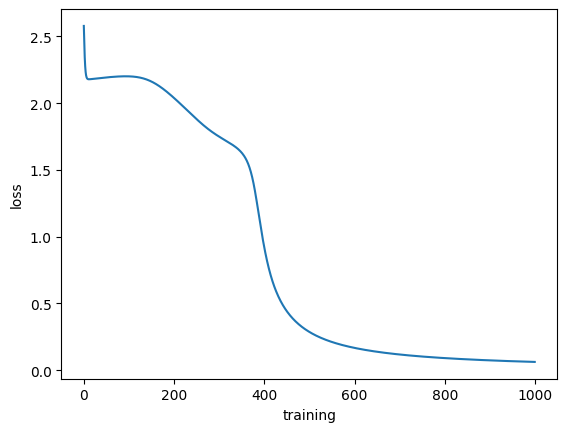

In [46]:
plt.plot(loss)
plt.ylabel('loss')
plt.xlabel('training')
plt.show()

In [47]:
def test(X):
    y_hat = []
    for x in X:
        forward_xh(x)
        forward_hy()
        y_hat.append(y_out)
    return y_hat

In [48]:
print(test(np.array([[0, 0], [0, 1], [1, 0], [1, 1]])))

[array([0.1273989 , 0.87286132]), array([0.92059784, 0.07922206]), array([0.9198644 , 0.07994897]), array([0.04027072, 0.9598802 ])]


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [84]:
model = keras.models.Sequential([
    keras.layers.Dense(6, activation='sigmoid'),
    keras.layers.Dense(4, activation='sigmoid'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [85]:
optimizer = keras.optimizers.SGD(learning_rate=5.0)
model.compile(optimizer=optimizer, loss='mse')

In [86]:
data_loc = 'https://github.com/dknife/ML/raw/main/data/'
df = pd.read_csv(data_loc+'nonlinear.csv')
X = df['x'].to_numpy().reshape(-1, 1)
y_label = df['y'].to_numpy()

In [90]:
model.fit(X, y_label, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3666 
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3638 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3645 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3658 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3650 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3647 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3654
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3670 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3640 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3659 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3658 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3668 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3626 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3688 
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


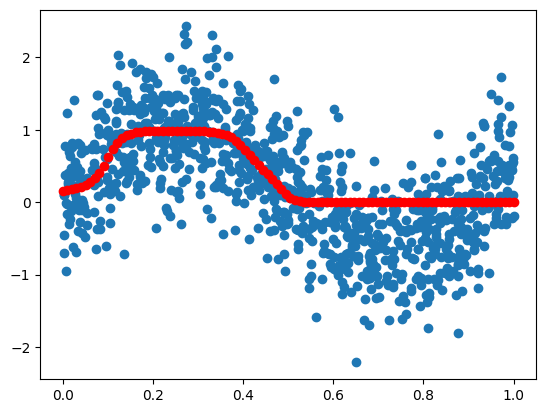

In [91]:
domain = np.linspace(0, 1, 100).reshape(-1, 1)
y_hat = model.predict(domain)
plt.scatter(df['x'], df['y'])
plt.scatter(domain, y_hat, color='r')